In [1]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # must be FIRST, before torch


import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

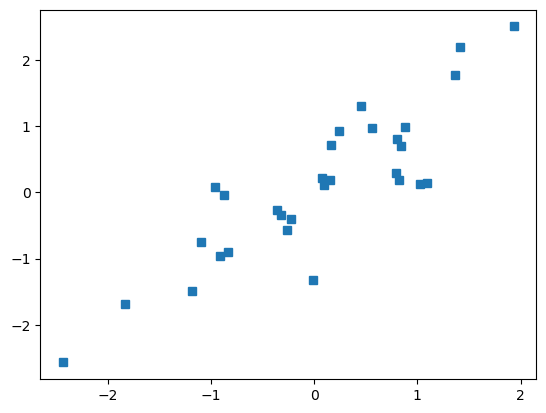

In [4]:
# create data

N = 30
x = torch.randn(N, 1)
y = x + torch.randn(N, 1) / 2

plt.plot(x, y, "s")
plt.show()

In [6]:
# build model
ANNreg = nn.Sequential(
    nn.Linear(1, 1),  # input layer
    nn.ReLU(),  # activation function
    nn.Linear(1, 1),  # output layer
)

ANNreg

Sequential(
  (0): Linear(in_features=1, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
)

In [11]:
learning_rate = 0.05

loss_fun = nn.MSELoss()

optimizer = torch.optim.SGD(ANNreg.parameters(), lr=learning_rate)

In [12]:
# train the model
numepochs = 500
losses = torch.zeros(numepochs)

for epochi in range(numepochs):
    # forward pass
    yHat = ANNreg(x)

    # compute loss
    loss = loss_fun(yHat, y)
    losses[epochi] = loss

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

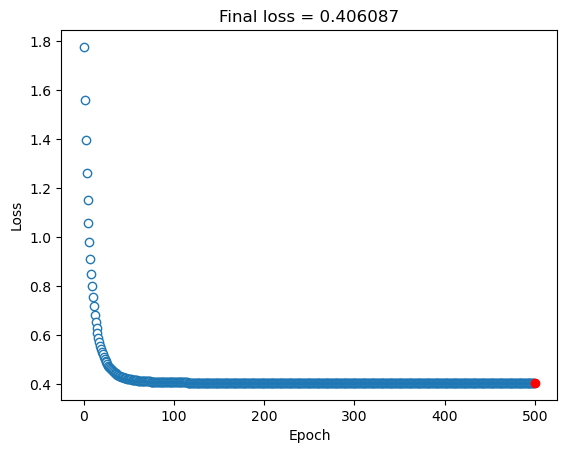

In [13]:
# show the losses

# final forward pass
predictions = ANNreg(x)

# final loss (MSE)
testloss = (predictions - y).pow(2).mean()

plt.plot(losses.detach(), "o", markerfacecolor="w", linewidth=0.1)
plt.plot(numepochs, testloss.detach(), "ro")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Final loss = %g" % testloss.item())
plt.show()

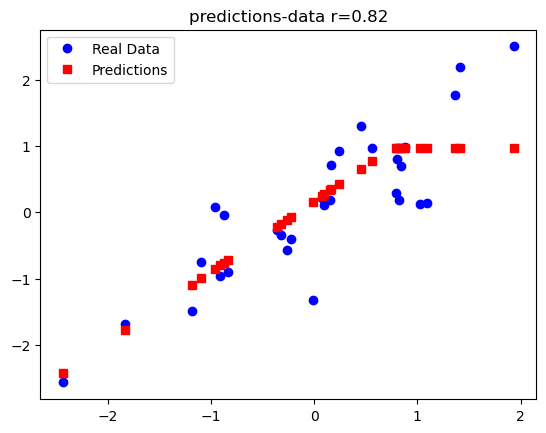

In [14]:
# plot the predictions and data

plt.plot(x, y, "bo", label="Real Data")
plt.plot(x, predictions.detach(), "rs", label="Predictions")

plt.title(f"predictions-data r={np.corrcoef(y.T, predictions.detach().T)[0, 1]:.2f}")

plt.legend()
plt.show()